# Fase 1: Preprocesado del Dataset
## Proyecto: Clasificador Over/Under 2.5 goles en partidos de fútbol

En este notebook se prepara el dataset para entrenar un modelo de clasificación binaria que predice si un partido de fútbol tendrá más de 2.5 goles (Over) o no (Under).

Fuentes de apoyo: Titanic: A Complete Beginner's Guide (https://www.kaggle.com/code/reighns/titanic-a-complete-beginner-s-guide).

## 1. Importar librerías

In [ ]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de sklearn para el preprocesado
from sklearn.model_selection import train_test_split  # para separar train/test
from sklearn.preprocessing import StandardScaler      # para escalar las features

# Configuración de los gráficos
plt.rcParams['figure.figsize'] = (10, 5)
sns.set(style='whitegrid')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

## 2. Carga y exploración inicial

El dataset se obtuvo del repositorio público **Kaggle: Club Football Match Data (2000-2025)**, que contiene partidos de 38 ligas de fútbol con estadísticas, rating ELO y cuotas de bookmakers.

Como el dataset ya viene completo y con muchas instancias, **no es necesario aumentar el set de datos**.

In [ ]:
# Cargar el CSV
df = pd.read_csv('Matches.csv', low_memory=False)

print('Filas:', len(df))
print('Columnas:', df.shape[1])

df.head()

Filas: 230557
Columnas: 48


,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F1,2000-07-29,NaN,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F1,2000-07-29,NaN,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Selección de columnas de interés

 Seleccionamos las columnas que vamos a usar:
 - Division: la liga donde se juega el partido (categórica)
 - HomeElo, AwayElo: rating ELO de cada equipo (numéricas, mide la fuerza del equipo)
 - Form3Home, Form5Home, Form3Away, Form5Away: puntos en los últimos 3 y 5 partidos
 - FTHome, FTAway: goles finales del partido que se usaran para crear el target

In [ ]:
columnas_interes = [
    'Division', 'HomeElo', 'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 'FTHome', 'FTAway'
]

df = df[columnas_interes]
print('Columnas seleccionadas:', {df.shape[1]})
df.head()

Columnas seleccionadas: {9}


,Division,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,FTHome,FTAway
0,F1,1686.34,1586.57,0.0,0.0,0.0,0.0,3.0,1.0
1,F1,1714.89,1642.51,0.0,0.0,0.0,0.0,3.0,1.0
2,F2,1465.08,1633.80,0.0,0.0,0.0,0.0,0.0,1.0
3,F1,1635.58,1624.22,0.0,0.0,0.0,0.0,0.0,1.0
4,F1,1734.34,1673.11,0.0,0.0,0.0,0.0,1.0,1.0


## 4. Limpieza de los datos: manejo de nulos por columna

El tutorial Titanic explica que no es buena idea eliminar todos los registros con nulos a ciegas, ni rellenarlos todos con la mediana sin pensar. Depende de cada columna.

In [ ]:
# Revisar nulos de las columnas seleccionadas
df[columnas_interes].isnull().sum()

,0
Division,0
HomeElo,88960
AwayElo,89029
Form3Home,1500
Form5Home,1500
Form3Away,1500
Form5Away,1500
FTHome,3
FTAway,3


**Decisiones:**
- 'HomeElo' y 'AwayElo' tienen ~38% de nulos (demasiados). Eliminamos esas filas porque imputar tantos valores distorsionaría la distribución.
- 'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away' tienen menos del 1% de nulos. Los imputamos con la mediana.
- 'FTHome' y 'FTAway' los necesitamos para crear el target, así que eliminamos las filas que los tengan nulos (son muy pocas).

In [ ]:
# 1. Eliminar filas sin ELO (muchos nulos, imputar distorsionaría)
filas_antes = len(df)
df = df.dropna(subset=['HomeElo', 'AwayElo'])
print(f'Filas eliminadas por ELO nulo: {filas_antes - len(df):,}')
print(f'Filas restantes: {len(df):,}')

Filas eliminadas por ELO nulo: 98,144
Filas restantes: 132,413


In [ ]:
# 2. Imputar nulos en las columnas Form con la mediana
form_cols = ['Form3Home', 'Form5Home', 'Form3Away', 'Form5Away']

for col in form_cols:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f'{col}: imputado con mediana = {mediana}')

print(f'\nNulos restantes en columnas Form: {df[form_cols].isnull().sum().sum()}')

Form3Home: imputado con mediana = 4.0
Form5Home: imputado con mediana = 7.0
Form3Away: imputado con mediana = 4.0
Form5Away: imputado con mediana = 7.0

Nulos restantes en columnas Form: 0


In [ ]:
# 3. Eliminar las pocas filas sin goles registrados (necesarias para el target)
df = df.dropna(subset=['FTHome', 'FTAway'])
print(f'Filas finales: {len(df):,}')

Filas finales: 132,411


## 5. Creación de la variable objetivo (target)

Como queremos predecir si el partido tendrá más de 2.5 goles, primero sumamos los goles de ambos equipos. Luego creamos una columna binaria:
- **1** si hubo más de 2.5 goles (Over)
- **0** si hubo 2.5 goles o menos (Under)

In [ ]:
# Sumar los goles del partido
df['TotalGoles'] = df['FTHome'] + df['FTAway']

# Crear el target con 1 si goles > 2.5, 0 si no
df['Over25'] = (df['TotalGoles'] > 2.5).astype(int)

# revisar si esta balanceado
print('Distribución del target:')
print(df['Over25'].value_counts())
print('\nEn porcentaje:')
print(df['Over25'].value_counts(normalize=True).round(3)*100)

Distribución del target:
Over25
0    67617
1    64794
Name: count, dtype: int64

En porcentaje:
Over25
0    51.1
1    48.9
Name: proportion, dtype: float64


El target está prácticamente balanceado (~49% Over, ~51% Under), lo cual es bueno porque significa que el modelo no tendrá un sesgo natural hacia una clase. No necesitamos aplicar técnicas de balanceo.

In [ ]:
##Eliminamos las columnas que solo usamos para crearlo (Esto no se puede correr dos veces seguidas sin volver a correr el codigo arriba)
# (FTHome, FTAway y TotalGoles ya no las necesitamos)
df = df.drop(columns=['FTHome', 'FTAway', 'TotalGoles'])
print('Columnas actuales:')
print(df.columns.tolist())

Columnas actuales:
['Division', 'HomeElo', 'AwayElo', 'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away', 'Over25']


## 6. Feature engineering: crear EloDiff

Agregamos una feature derivada: la diferencia entre el ELO del equipo local y el del visitante. Esto le da al modelo una pista directa de qué tan desbalanceado es el partido (si la diferencia es grande, probablemente el favorito meta muchos goles; si es cercana a 0, los equipos están parejos).

In [ ]:
# Diferencia de ELO: positivo significa que el local es más fuerte
df['EloDiff'] = df['HomeElo'] - df['AwayElo']

df[['HomeElo', 'AwayElo', 'EloDiff']].round(2)

,HomeElo,AwayElo,EloDiff
0,1686.34,1586.57,99.77
1,1714.89,1642.51,72.38
2,1465.08,1633.80,-168.72
3,1635.58,1624.22,11.36
4,1734.34,1673.11,61.23
...,...,...,...
230552,1339.21,1544.15,-204.94
230553,1544.16,1433.67,110.49
230554,1473.67,1569.98,-96.31
230555,1574.90,1525.76,49.14


## 7. Preprocesado de la variable categórica: One-Hot Encoding

La columna **Division** tiene los códigos de las ligas (por ejemplo, E0 = Premier League, SP1 = La Liga, etc.). Como los modelos de machine learning trabajan con números, tenemos que convertir esta variable categórica en variables binarias.

El tutorial Titanic sugiere el siguiente metodo para nuestro contexto:
- **One-Hot Encoding**: crea una columna binaria por cada categoría, sin asumir un orden. Como las ligas no tienen un orden jerárquico entre ellas, este metodo nos sirve.

In [ ]:
# Ver cuántas ligas hay
print(f'Cantidad de ligas: {df['Division'].nunique()}')
print(f'Ejemplos: {df['Division'].unique()[10:]}')

Cantidad de ligas: 26
Ejemplos: ['E2' 'I2' 'SP2' 'SP1' 'I1' 'SC0' 'G1' 'SC1' 'NOR' 'DEN' 'AUT' 'SWE' 'POL'
 'ROM' 'FIN' 'RUS']


In [ ]:
# Aplicamos One-Hot Encoding a la columna Division
# pd.get_dummies crea una columna binaria por cada categoría
# prefix='Liga' agrega 'Liga_' al inicio del nombre de cada columna nueva (ej: Liga_E0, Liga_SP1)
# dtype=int hace que las columnas sean 0/1 directamente (en vez de True/False)
df = pd.get_dummies(df, columns=['Division'], prefix='Liga', dtype=int)

# Contar cuántas columnas de liga se crearon
columnas_liga = [c for c in df.columns if c.startswith('Liga_')]

print(f'Total de columnas después de One-Hot: {df.shape[1]}')
print(f'Columnas de liga creadas: {len(columnas_liga)}')
df.head()

Total de columnas después de One-Hot: 34
Columnas de liga creadas: 26


,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,Over25,EloDiff,Liga_AUT,Liga_B1,...,Liga_P1,Liga_POL,Liga_ROM,Liga_RUS,Liga_SC0,Liga_SC1,Liga_SP1,Liga_SP2,Liga_SWE,Liga_T1
0,1686.34,1586.57,0.0,0.0,0.0,0.0,1,99.77,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1714.89,1642.51,0.0,0.0,0.0,0.0,1,72.38,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1465.08,1633.80,0.0,0.0,0.0,0.0,0,-168.72,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1635.58,1624.22,0.0,0.0,0.0,0.0,0,11.36,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1734.34,1673.11,0.0,0.0,0.0,0.0,0,61.23,0,0,...,0,0,0,0,0,0,0,0,0,0


## 8. Separación en features (X) y target (y)

Antes de hacer el split train/test, separamos las features (X) del target (y).

In [ ]:
# y = lo que queremos predecir (el target)
y = df['Over25']

# X = todas las demás columnas (las features)
X = df.drop(columns=['Over25'])

print(f'Shape de X (features): {X.shape}')
print(f'Shape de y (target):   {y.shape}')

Shape de X (features): (132411, 33)
Shape de y (target):   (132411,)


## 9. Separación en sets de entrenamiento y prueba

Usamos `train_test_split` de sklearn para dividir los datos:
- **80%** para entrenar el modelo (`x_train`)
- **20%** para evaluarlo (`x_test`)

Usamos `random_state=0` para que la división sea reproducible (que dé el mismo resultado cada vez que corramos el notebook), igual que en el tutorial Titanic.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    test_size=0.2,
    random_state=0
)

print(f'x_train: {x_train.shape}, y_train: {y_train.shape}')
print(f'x_test:  {x_test.shape}, y_test:  {y_test.shape}')
print()
print(f'Proporción de Over en train: {y_train.mean():.3f}')
print(f'Proporción de Over en test:  {y_test.mean():.3f}')

x_train: (105928, 33), y_train: (105928,)
x_test:  (26483, 33), y_test:  (26483,)

Proporción de Over en train: 0.489
Proporción de Over en test:  0.489


## 10. Escalamiento de las features numéricas

Las features numéricas (ELO, Forma) están en escalas muy distintas:
- El ELO va de ~1200 a ~2100
- La forma va de 0 a 9 o de 0 a 15

Si dejamos los datos así, las features con valores más grandes (como ELO) tendrán más peso artificialmente.

Las columnas de liga (Liga_E0, Liga_SP1, etc.) NO se escalan porque ya son 0/1.

In [ ]:
# Lista de columnas numéricas que sí queremos escalar
columnas_numericas = [
    'HomeElo', 'AwayElo', 'EloDiff',
    'Form3Home', 'Form5Home', 'Form3Away', 'Form5Away'
]

# Crear el scaler
sc = StandardScaler()

# Hacemos copias para no modificar los originales
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

# Ajustar y transformar las columnas numéricas en train
x_train_scaled[columnas_numericas] = sc.fit_transform(x_train[columnas_numericas])

# Aplicar la misma transformación al test (sin volver a ajustar)
x_test_scaled[columnas_numericas] = sc.transform(x_test[columnas_numericas])

print('Estadísticas de las features numéricas despues d escalar (train):')
print(x_train_scaled[columnas_numericas].describe().round(3).loc[['mean', 'std', 'min', 'max']])

Estadísticas de las features numéricas despues d escalar (train):
      HomeElo  AwayElo  EloDiff  Form3Home  Form5Home  Form3Away  Form5Away
mean    0.000   -0.000    0.000      0.000     -0.000     -0.000     -0.000
std     1.000    1.000    1.000      1.000      1.000      1.000      1.000
min    -2.830   -2.829   -4.227     -1.668     -2.053     -1.778     -2.131
max     3.728    3.748    4.162      2.127      2.542      1.996      2.457


In [ ]:
#Este bloque de codigo es para guardar los csv
import os
os.makedirs('data_procesada', exist_ok=True)
x_train_scaled.to_csv('data_procesada/x_train.csv', index=False)
x_test_scaled.to_csv('data_procesada/x_test.csv', index=False)
y_train.to_csv('data_procesada/y_train.csv', index=False)
y_test.to_csv('data_procesada/y_test.csv', index=False)

# Fase 2: Construcción y evaluación del modelo

## Estado del arte (paper de referencia)

La selección de los hiperparámetros y las métricas están respaldados por el siguiente artículo:

> Atta Mills, E. F. E., Deng, Z., Zhong, Z., & Li, J. (2024). *Data-driven prediction of soccer outcomes using enhanced machine and deep learning techniques*. Journal of Big Data, 11(170). https://doi.org/10.1186/s40537-024-01008-2

Este paper evalúa siete modelos diferentes (Logistic Regression, XGBoost, Random Forest, SVM, Naive Bayes, Feedforward Neural Network y Vanilla RNN) para el problema de predicción Over/Under 2.5 goles en fútbol, usando como métricas accuracy, precision, recall, F1-score y matriz de confusión.

Del paper nos quedamos con:
- **El modelo:** Feedforward Neural Network (red neuronal hacia adelante).
- **La arquitectura base:** 4 capas ocultas (64, 128, 128, 128 unidades), activación ReLU, dropout 0.5, batch normalization.
- **El optimizador:** Adam con learning rate 0.001 (el paper usa Yogi, pero Adam es la versión estándar en Keras y muy similar).
- **Las métricas:** accuracy, precision, recall, F1-score, matriz de confusión.

## 2.1. Construcción del modelo


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Fijamos semillas para que los resultados sean reproducibles
import numpy as np
np.random.seed(42)
tf.random.set_seed(42)

### Definición de la arquitectura

Definimos una red neuronal Feedforward siguiendo la arquitectura del paper:

| Componente | Valor |
|---|---|
| Capa de entrada | 33 neuronas (una por feature) |
| Capa oculta 1 | 64 unidades, ReLU |
| Capa oculta 2 | 128 unidades, ReLU |
| Capa oculta 3 | 128 unidades, ReLU |
| Capa oculta 4 | 128 unidades, ReLU |
| Capa de salida | 1 neurona, Sigmoid |
| Dropout | 0.5 después de cada capa oculta |
| Batch Normalization | Después de cada capa oculta |

**¿Qué hace cada cosa?**
- **Dense:** capa totalmente conectada (cada neurona está conectada con todas las de la capa anterior).
- **ReLU:** función de activación que deja pasar valores positivos y pone los negativos en 0.
- **Sigmoid (en la salida):** comprime el resultado a un valor entre 0 y 1, que interpretamos como probabilidad de que sea Over 2.5.
- **Dropout 0.5:** durante el entrenamiento, apaga aleatoriamente el 50% de las neuronas en cada paso. Previene el sobreajuste.
- **Batch Normalization:** normaliza las activaciones entre capas, lo que hace el entrenamiento más estable y rápido.

In [45]:
# Número de features de entrada (lo sacamos directamente de x_train_scaled)
n_features = x_train_scaled.shape[1]
print(f'Número de features de entrada: {n_features}')


modelo = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

# Mostrar resumen de la arquitectura
modelo.summary()

Número de features de entrada: 33


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

### Compilación del modelo

Aquí configuramos cómo el modelo va a aprender:

- **Optimizer:** Adam con learning rate 0.001.
- **Loss:** `binary_crossentropy`, la función de pérdida estándar para clasificación binaria.
- **Metrics:** accuracy, para ir viendo el desempeño durante el entrenamiento.

In [ ]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Modelo compilado correctamente.')

Modelo compilado correctamente.


## 2.2. Entrenamiento del modelo

Configuración:
- **Epochs:** 30 (cuántas veces pasa por todo el dataset).
- **Batch size:** 64 (cuántos partidos procesa antes de actualizar los pesos).
- **Validation split:** 20% del train se usa como validación para monitorear si hay overfitting.
- **Early stopping:** corta el entrenamiento si la validación no mejora en 10 epochs, evitando overfitting.

In [ ]:
# Early stopping: detiene el entrenamiento si val_accuracy no mejora en 10 epochs
# y restaura los mejores pesos automáticamente
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Entrenar el modelo
# Usamos x_train_scaled y y_train que ya generamos en la Fase 1
history = modelo.fit(
    x_train_scaled, y_train,
    validation_split=0.2,
    epochs=50, # el epoch 50 casi siempre se restorea porque fue el mejor, irrelevante hacer mas echos
    batch_size=32,
    callbacks=[early_stopping],
    verbose=2
)

Epoch 1/50
2649/2649 - 7s - 3ms/step - accuracy: 0.5087 - loss: 0.7017 - val_accuracy: 0.5236 - val_loss: 0.6902
Epoch 2/50
2649/2649 - 7s - 3ms/step - accuracy: 0.5230 - loss: 0.6932 - val_accuracy: 0.5400 - val_loss: 0.6887
Epoch 3/50
2649/2649 - 5s - 2ms/step - accuracy: 0.5342 - loss: 0.6904 - val_accuracy: 0.5482 - val_loss: 0.6874
Epoch 4/50
2649/2649 - 7s - 3ms/step - accuracy: 0.5388 - loss: 0.6890 - val_accuracy: 0.5494 - val_loss: 0.6868
Epoch 5/50
2649/2649 - 6s - 2ms/step - accuracy: 0.5412 - loss: 0.6883 - val_accuracy: 0.5524 - val_loss: 0.6862
Epoch 6/50
2649/2649 - 8s - 3ms/step - accuracy: 0.5432 - loss: 0.6872 - val_accuracy: 0.5524 - val_loss: 0.6857
Epoch 7/50
2649/2649 - 5s - 2ms/step - accuracy: 0.5502 - loss: 0.6866 - val_accuracy: 0.5514 - val_loss: 0.6854
Epoch 8/50
2649/2649 - 7s - 2ms/step - accuracy: 0.5469 - loss: 0.6867 - val_accuracy: 0.5536 - val_loss: 0.6853
Epoch 9/50
2649/2649 - 5s - 2ms/step - accuracy: 0.5476 - loss: 0.6864 - val_accuracy: 0.5540 - 

### Visualización del entrenamiento

Estas gráficas nos ayudan a entender cómo aprendió el modelo:
Sabemos que si la curva de **training accuracy** sube mucho más que la de **validation accuracy**, hay overfitting (el modelo memorizó).
Si ambas se quedan bajas y planas, hay underfitting (el modelo no aprendió suficiente).

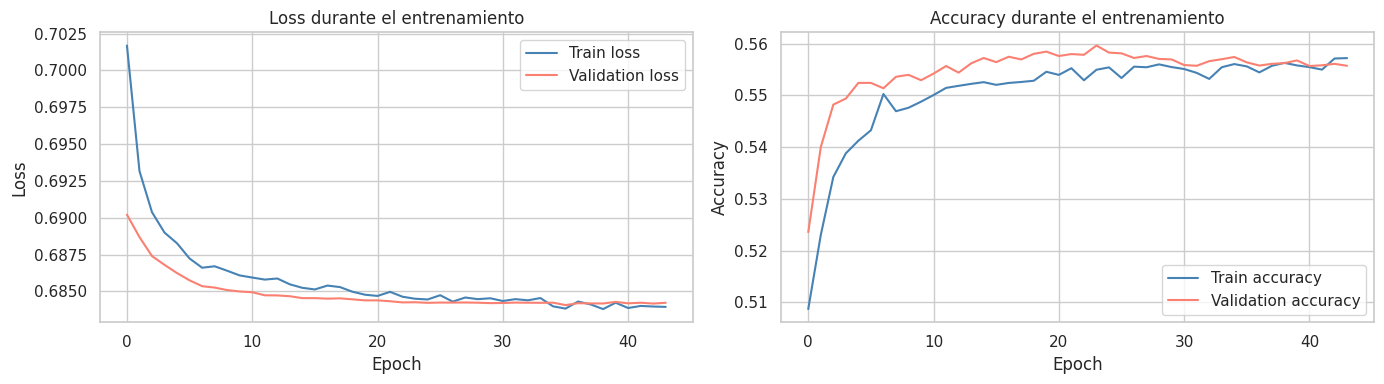

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Curva de loss
axes[0].plot(history.history['loss'], label='Train loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation loss', color='salmon')
axes[0].set_title('Loss durante el entrenamiento')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Curva de accuracy
axes[1].plot(history.history['accuracy'], label='Train accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy', color='salmon')
axes[1].set_title('Accuracy durante el entrenamiento')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [50]:
import os

ruta_modelo = '/content/drive/MyDrive/modeloFutbol/'
os.makedirs(ruta_modelo, exist_ok=True)

modelo.save(ruta_modelo + 'modelo_overunder.keras')

# guardar el scaler porque se ocupa para preprocesar nuevos datos
import joblib
joblib.dump(sc, ruta_modelo + 'scaler.pkl')

# guardar las columnas que el modelo espera para reconstruir partidos nuevos
import pickle
with open(ruta_modelo + 'columnas.pkl', 'wb') as f:
    pickle.dump(list(x_train_scaled.columns), f)
with open(ruta_modelo + 'columnas_numericas.pkl', 'wb') as f:
    pickle.dump(columnas_numericas, f)

print('Modelo y scaler guardados en Drive')
print(f'Ruta: {ruta_modelo}')

Modelo y scaler guardados en Drive
Ruta: /content/drive/MyDrive/modeloFutbol/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2.3. Evaluación del modelo

Evaluamos el modelo en el set de **test** usando las métricas seleccionadas:

- **Accuracy:** porcentaje de predicciones correctas en total.
- **Precision:** de los partidos que predijimos como Over, ¿cuántos realmente fueron Over?
- **Recall:** de los partidos que realmente fueron Over, ¿cuántos detectamos?
- **F1-score:** media armónica entre precision y recall.
- **Matriz de confusión:** detalla cómo se distribuyen los aciertos y errores entre clases.

In [ ]:
# Evaluación general con Keras
loss_test, accuracy_test = modelo.evaluate(x_test_scaled, y_test, verbose=0)
print(f'Loss en test:     {loss_test:.4f}')
print(f'Accuracy en test: {accuracy_test:.4f}')

Loss en test:     0.6842
Accuracy en test: 0.5547


In [ ]:
# Generar predicciones
# El modelo devuelve probabilidades (entre 0 y 1)
# Las convertimos a 0/1 con umbral 0.5
y_pred_prob = modelo.predict(x_test_scaled, verbose=0).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Calcular métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('============================')
print('Métricas en el set de TEST')
print('============================')
print(f'Accuracy:  {acc:.4f}  ({acc*100:.2f}%)')
print(f'Precision: {prec:.4f}  ({prec*100:.2f}%)')
print(f'Recall:    {rec:.4f}  ({rec*100:.2f}%)')
print(f'F1-score:  {f1:.4f}  ({f1*100:.2f}%)')

Métricas en el set de TEST
Accuracy:  0.5547  (55.47%)
Precision: 0.5545  (55.45%)
Recall:    0.4537  (45.37%)
F1-score:  0.4991  (49.91%)


In [ ]:
# Reporte detallado por clase
print('Reporte de clasificación detallado:')
print(classification_report(y_test, y_pred, target_names=['Under 2.5', 'Over 2.5']))

Reporte de clasificación detallado:
              precision    recall  f1-score   support

   Under 2.5       0.55      0.65      0.60     13537
    Over 2.5       0.55      0.45      0.50     12946

    accuracy                           0.55     26483
   macro avg       0.55      0.55      0.55     26483
weighted avg       0.55      0.55      0.55     26483



### Matriz de confusión

La matriz de confusión nos muestra exactamente cómo se está equivocando el modelo:

| | Predicción Under | Predicción Over |
|---|---|---|
| **Real Under** | True Negative (acierto) | False Positive (error) |
| **Real Over** | False Negative (error) | True Positive (acierto) |

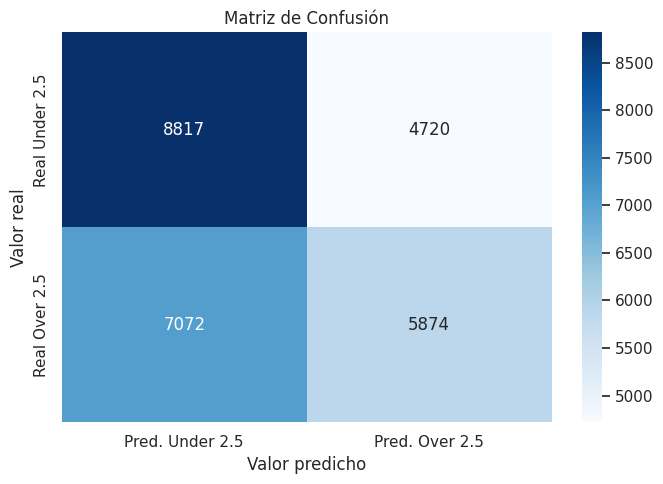

True Negatives  (Under correctos):           8,817
False Positives (predijo Over, era Under):   4,720
False Negatives (predijo Under, era Over):   7,072
True Positives  (Over correctos):            5,874


In [ ]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred. Under 2.5', 'Pred. Over 2.5'],
    yticklabels=['Real Under 2.5', 'Real Over 2.5']
)
plt.title('Matriz de Confusión')
plt.ylabel('Valor real')
plt.xlabel('Valor predicho')
plt.tight_layout()
plt.show()

# resimen
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Under correctos):           {tn:,}')
print(f'False Positives (predijo Over, era Under):   {fp:,}')
print(f'False Negatives (predijo Under, era Over):   {fn:,}')
print(f'True Positives  (Over correctos):            {tp:,}')

### Ejemplo de predicciones del modelo

Veamos cómo se ven las predicciones del modelo sobre los primeros 10 partidos del set de test.

In [ ]:
import pandas as pd

ejemplo = pd.DataFrame({
    'Probabilidad Over': y_pred_prob[:10].round(3),
    'Predicción': ['Over 2.5' if p > 0.5 else 'Under 2.5' for p in y_pred_prob[:10]],
    'Realidad': ['Over 2.5' if r == 1 else 'Under 2.5' for r in y_test.values[:10]],
    'Acierto': ['Si' if p == r else 'No' for p, r in zip(y_pred[:10], y_test.values[:10])]
})
ejemplo

,Probabilidad Over,Predicción,Realidad,Acierto
0,0.454,Under 2.5,Under 2.5,Si
1,0.535,Over 2.5,Over 2.5,Si
2,0.484,Under 2.5,Under 2.5,Si
3,0.508,Over 2.5,Over 2.5,Si
4,0.579,Over 2.5,Over 2.5,Si
5,0.462,Under 2.5,Over 2.5,No
6,0.503,Over 2.5,Over 2.5,Si
7,0.484,Under 2.5,Under 2.5,Si
8,0.458,Under 2.5,Under 2.5,Si
9,0.536,Over 2.5,Under 2.5,No


# CARGAR EL MODELO PARA UTILIZARLO

In [46]:
import tensorflow as tf
from tensorflow import keras
import joblib
import pickle
import pandas as pd
import numpy as np

ruta_modelo = '/content/drive/MyDrive/modeloFutbol/'

modelo = keras.models.load_model(ruta_modelo + 'modelo_overunder.keras')
sc = joblib.load(ruta_modelo + 'scaler.pkl')

with open(ruta_modelo + 'columnas.pkl', 'rb') as f:
    columnas_modelo = pickle.load(f)
with open(ruta_modelo + 'columnas_numericas.pkl', 'rb') as f:
    columnas_numericas = pickle.load(f)

print('Modelo cargado')
modelo.summary()

Modelo cargado


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,869 (50.27 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,580 (33.52 KB)

In [47]:
# ===========================================
# FUNCIÓN PARA PREDECIR CUALQUIER PARTIDO
# ===========================================

def predecir_partido(liga, home_elo, away_elo, form3_home, form5_home, form3_away, form5_away):
    # Construir el partido usando las columnas guardadas
    partido = {col: 0 for col in columnas_modelo}
    partido['HomeElo']   = home_elo
    partido['AwayElo']   = away_elo
    partido['EloDiff']   = home_elo - away_elo
    partido['Form3Home'] = form3_home
    partido['Form5Home'] = form5_home
    partido['Form3Away'] = form3_away
    partido['Form5Away'] = form5_away

    columna_liga = f'Liga_{liga}'
    if columna_liga in partido:
        partido[columna_liga] = 1
    else:
        print(f"Liga '{liga}' no reconocida.")
        return

    partido_df = pd.DataFrame([partido])[columnas_modelo]
    partido_df[columnas_numericas] = sc.transform(partido_df[columnas_numericas])

    prob = modelo.predict(partido_df.values, verbose=0)[0][0]
    pred = 'Over 2.5' if prob > 0.5 else 'Under 2.5'

    print(f"Liga {liga} | Local ELO {home_elo} vs Visit ELO {away_elo} (diff {home_elo-away_elo:+d})")
    print(f"  → {pred}  (prob. Over: {prob*100:.1f}%)\n")


# ===========================================
# EJEMPLOS
# ===========================================

print("Ejemplo 1: Real Madrid (fuerte, local) vs equipo chico")
predecir_partido(liga='SP1', home_elo=1980, away_elo=1490,
                 form3_home=7, form5_home=11, form3_away=3, form5_away=5)

print("Ejemplo 2: Clásico parejo (dos equipos top)")
predecir_partido(liga='SP1', home_elo=1920, away_elo=1930,
                 form3_home=6, form5_home=10, form3_away=7, form5_away=12)



Ejemplo 1: Real Madrid (fuerte, local) vs equipo chico
Liga SP1 | Local ELO 1980 vs Visit ELO 1490 (diff +490)
  → Over 2.5  (prob. Over: 71.5%)

Ejemplo 2: Clásico parejo (dos equipos top)
Liga SP1 | Local ELO 1920 vs Visit ELO 1930 (diff -10)
  → Over 2.5  (prob. Over: 51.7%)



In [44]:
def pedir_int(mensaje, minimo, maximo):
    """Pide un entero hasta que el usuario meta uno válido en el rango."""
    while True:
        try:
            valor = int(input(mensaje))
            if minimo <= valor <= maximo:
                return valor
            print(f"  Debe estar entre {minimo} y {maximo}.")
        except ValueError:
            print("  Eso no es un número válido.")


# Liga
ligas_validas = [c.replace('Liga_', '') for c in columnas_modelo if c.startswith('Liga_')]
while True:
    liga = input("Liga (ej. SP1, E0, D1, I1): ").strip().upper()
    if liga in ligas_validas:
        break
    print(f"  Liga no reconocida. Opciones: {', '.join(ligas_validas)}")

# Resto de datos
home_elo   = pedir_int("ELO del equipo local (1000-2200): ", 1000, 2200)
away_elo   = pedir_int("ELO del equipo visitante (1000-2200): ", 1000, 2200)
form3_home = pedir_int("Puntos del local en los últimos 3 partidos (0-9): ", 0, 9)
form5_home = pedir_int("Puntos del local en los últimos 5 partidos (0-15): ", 0, 15)
form3_away = pedir_int("Puntos del visitante en los últimos 3 partidos (0-9): ", 0, 9)
form5_away = pedir_int("Puntos del visitante en los últimos 5 partidos (0-15): ", 0, 15)

predecir_partido(liga, home_elo, away_elo, form3_home, form5_home, form3_away, form5_away)

Liga (ej. SP1, E0, D1, I1): SP1
ELO del equipo local (1000-2200): 2001
ELO del equipo visitante (1000-2200): 1400
Puntos del local en los últimos 3 partidos (0-9): 9
Puntos del local en los últimos 5 partidos (0-15): 9
Puntos del visitante en los últimos 3 partidos (0-9): 3
Puntos del visitante en los últimos 5 partidos (0-15): 4
Liga SP1 | Local ELO 2001 vs Visit ELO 1400 (diff +601)
  → Over 2.5  (prob. Over: 76.2%)

